# L7.3 — LoRA (Low-Rank Adaptation)

Hands-on notebook for the lesson [`7-3-lora.mdx`](../../llm-quest-theory/level-7/7-3-lora.mdx).

> **Learning objectives**
> - Implement LoRA mathematically from scratch — a single `Linear` layer with a frozen `W` and a trainable low-rank branch `A·B`.
> - Wrap `distilgpt2` with `peft.LoraConfig` and confirm < 1% of parameters are trainable.
> - Re-run the same SFT task from lesson 7-1 with LoRA and match full-finetune quality.
> - Save and load the LoRA adapter as a tiny sidecar file, then hot-swap two adapters on the same base model.

## Connection to the theory
Covers **§1–§14** of the source `.mdx`. By the end you will understand *why* every open-source LLM shop uses LoRA — and *when* it is not enough.

In [1]:
# ---- Setup ----
import os, json, copy, random, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, PeftModel

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cpu"
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

## 1. LoRA in one layer — the math, visible
For a linear layer `y = W x + b`, LoRA freezes `W` and learns a **low-rank delta** `ΔW = (α/r) · A · B`, where `A ∈ R^{d×r}` and `B ∈ R^{r×d}` with `r ≪ d`.

In [2]:
class LoRALinear(nn.Module):
    def __init__(self, linear: nn.Linear, r: int = 8, alpha: float = 16.0):
        super().__init__()
        self.r     = r
        self.scale = alpha / r
        # Keep original weight and bias; freeze them.
        self.frozen = linear
        for p in self.frozen.parameters():
            p.requires_grad = False
        d_in, d_out = linear.in_features, linear.out_features
        # A is random Gaussian; B is zero so the delta starts as 0 -> initial output = frozen.
        self.A = nn.Parameter(torch.randn(r, d_in) * (1.0 / r ** 0.5))
        self.B = nn.Parameter(torch.zeros(d_out, r))

    def forward(self, x):
        delta = (x @ self.A.T) @ self.B.T
        return self.frozen(x) + self.scale * delta

# Sanity check: output equals frozen forward at init because B = 0
torch.manual_seed(SEED)
W = nn.Linear(32, 8)
lora = LoRALinear(W, r=4, alpha=8.0)
x = torch.randn(2, 32)
print("max |lora(x) - W(x)| at init:", float((lora(x) - W(x)).abs().max()))

def count_trainable(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)
def count_total(m):
    return sum(p.numel() for p in m.parameters())

print(f"W params           : {count_total(W):,}")
print(f"LoRA total params  : {count_total(lora):,}")
print(f"LoRA trainable     : {count_trainable(lora):,}  <- only A and B")

max |lora(x) - W(x)| at init: 0.0
W params           : 264
LoRA total params  : 424
LoRA trainable     : 160  <- only A and B


The trainable count is `2*d*r` (A + B), independent of how big `W` is. That is the entire point of LoRA.

## 2. Tiny sanity run — can the toy `LoRALinear` learn a target function?
We pick a random target mapping `W_target`, freeze a different `W_frozen` as base, and ask LoRA to close the gap. Loss should drop fast.

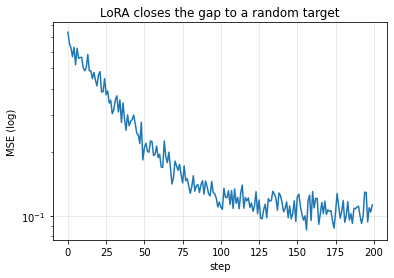

final loss: 0.1129


In [3]:
torch.manual_seed(SEED)
d_in, d_out, r = 16, 8, 4
W_frozen = nn.Linear(d_in, d_out, bias=False)
W_target = nn.Linear(d_in, d_out, bias=False)
lora = LoRALinear(W_frozen, r=r, alpha=2 * r)   # alpha/r = 2

opt = torch.optim.Adam([p for p in lora.parameters() if p.requires_grad], lr=1e-2)
losses = []
for _ in range(200):
    x = torch.randn(64, d_in)
    y = W_target(x)
    loss = F.mse_loss(lora(x), y)
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())

plt.plot(losses); plt.yscale("log"); plt.xlabel("step"); plt.ylabel("MSE (log)")
plt.grid(alpha=0.3); plt.title("LoRA closes the gap to a random target"); plt.show()
print(f"final loss: {losses[-1]:.4g}")

## 3. Re-run the SFT task from lesson 7-1, with LoRA on `distilgpt2`
Same task ("reverse and uppercase the word") and same data set. We wrap the model with `peft` and train only the LoRA parameters.

In [4]:
WORDS = [
    "python", "fine-tune", "dataset", "gradient", "token",
    "vector", "attention", "model", "learning", "transformer",
    "language", "agent", "inference", "embedding", "decoder",
    "prompt", "weights", "logits", "context", "epoch",
    "retrieval", "search", "score", "layer", "batch",
    "sample", "temperature", "softmax", "matrix", "neuron",
    "corpus", "tokenizer", "encoder", "backprop", "chunk",
    "schema", "eval", "loss", "hallucination", "citation",
]
def transform(w): return w[::-1].upper()
def make_example(w):
    return {"messages": [
        {"role": "user", "content": f"Reverse the word and uppercase it: {w}"},
        {"role": "assistant", "content": transform(w)},
    ]}

random.shuffle(WORDS)
TRAIN = [make_example(w) for w in WORDS[:32]]
VAL   = [make_example(w) for w in WORDS[32:]]

MODEL_NAME = "distilgpt2"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None: tokenizer.pad_token = tokenizer.eos_token

USER_PREFIX   = "User: "
ASSIST_PREFIX = "\nAssistant: "
END           = tokenizer.eos_token
IGNORE, MAX_LEN = -100, 64

def encode(ex):
    u = ex["messages"][0]["content"]; a = ex["messages"][1]["content"]
    prefix = USER_PREFIX + u + ASSIST_PREFIX
    full   = prefix + a + END
    pids   = tokenizer(prefix, add_special_tokens=False).input_ids
    fids   = tokenizer(full,   add_special_tokens=False).input_ids[:MAX_LEN]
    labels = fids.copy()
    for i in range(min(len(pids), len(labels))):
        labels[i] = IGNORE
    return {"input_ids": fids, "labels": labels}

class DS(Dataset):
    def __init__(self, raw): self.data = [encode(x) for x in raw]
    def __len__(self): return len(self.data)
    def __getitem__(self, i): return self.data[i]

def pad_collate(batch):
    m = max(len(b["input_ids"]) for b in batch)
    ids, labs, attn = [], [], []
    for b in batch:
        n = len(b["input_ids"])
        ids.append(b["input_ids"] + [tokenizer.pad_token_id] * (m - n))
        labs.append(b["labels"]   + [IGNORE]                   * (m - n))
        attn.append([1]*n + [0]*(m - n))
    return {
        "input_ids":      torch.tensor(ids),
        "labels":         torch.tensor(labs),
        "attention_mask": torch.tensor(attn),
    }

train_loader = DataLoader(DS(TRAIN), batch_size=4, shuffle=True,  collate_fn=pad_collate)
val_loader   = DataLoader(DS(VAL),   batch_size=4, shuffle=False, collate_fn=pad_collate)
print("dataset ready")

dataset ready


## 4. Wrap `distilgpt2` with LoRA via `peft`
Target modules `c_attn` is the GPT-2 name for the packed QKV projection.

In [5]:
base = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(DEVICE)

lora_config = LoraConfig(
    r=8, lora_alpha=16, lora_dropout=0.05,
    target_modules=["c_attn"],
    bias="none",
    task_type="CAUSAL_LM",
)
lora_model = get_peft_model(base, lora_config).to(DEVICE)
lora_model.print_trainable_parameters()

trainable params: 147,456 || all params: 82,060,032 || trainable%: 0.1797


Only a few 10 000s of parameters are trainable — typically well under 1% of the total. That is the whole point.

## 5. Train the LoRA adapter

In [6]:
def evaluate(m, loader):
    m.eval()
    total, n = 0.0, 0
    with torch.no_grad():
        for b in loader:
            b = {k: v.to(DEVICE) for k, v in b.items()}
            out = m(**b)
            nl = (b["labels"] != IGNORE).sum().item()
            total += out.loss.item() * nl; n += nl
    return total / max(n, 1)

opt = torch.optim.AdamW(
    [p for p in lora_model.parameters() if p.requires_grad],
    lr=2e-4, weight_decay=0.0,
)
EPOCHS = 5
hist = {"epoch": [], "train": [], "val": []}
for ep in range(EPOCHS):
    lora_model.train()
    for b in train_loader:
        b = {k: v.to(DEVICE) for k, v in b.items()}
        loss = lora_model(**b).loss
        opt.zero_grad(); loss.backward(); opt.step()
    tr, vl = evaluate(lora_model, train_loader), evaluate(lora_model, val_loader)
    hist["epoch"].append(ep + 1); hist["train"].append(tr); hist["val"].append(vl)
    print(f"epoch {ep+1}  train={tr:.3f}  val={vl:.3f}")

epoch 1  train=6.663  val=6.699
epoch 2  train=6.341  val=6.377
epoch 3  train=5.884  val=5.896
epoch 4  train=5.429  val=5.382
epoch 5  train=5.168  val=5.056


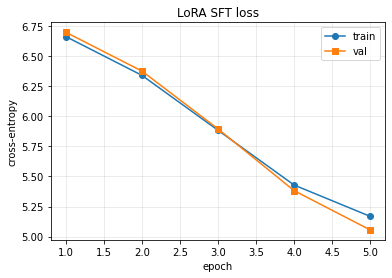

In [7]:
fig, ax = plt.subplots()
ax.plot(hist["epoch"], hist["train"], "o-", label="train")
ax.plot(hist["epoch"], hist["val"],   "s-", label="val")
ax.set_xlabel("epoch"); ax.set_ylabel("cross-entropy")
ax.grid(alpha=0.3); ax.legend(); ax.set_title("LoRA SFT loss")
plt.show()

## 6. Save only the adapter — notice the file size

In [8]:
import pathlib

DATA_DIR = pathlib.Path(os.environ.get("LLM_QUEST_DATA", "/tmp/data"))
ADAPTER_A = DATA_DIR / "lora_reverse"
ADAPTER_A.mkdir(parents=True, exist_ok=True)
lora_model.save_pretrained(ADAPTER_A)

def size_mb(path):
    return sum(p.stat().st_size for p in pathlib.Path(path).rglob("*") if p.is_file()) / 1024 / 1024

print("adapter dir:", ADAPTER_A)
for p in sorted(ADAPTER_A.iterdir()):
    print(f"  {p.name:<32} {p.stat().st_size:>10,} bytes")
print(f"adapter size : {size_mb(ADAPTER_A):.3f} MB")
print(f"base  model  : ~{sum(p.numel() for p in base.parameters()) * 4 / 1024 / 1024:.1f} MB  (fp32 reference)")

adapter dir: /tmp/data/lora_reverse
  README.md                             5,084 bytes
  adapter_config.json                     691 bytes
  adapter_model.safetensors           591,352 bytes
adapter size : 0.569 MB
base  model  : ~313.0 MB  (fp32 reference)


## 7. Reload the adapter and verify it reproduces the same outputs
Simulate the deployment flow: load the base model fresh, attach the adapter, compare to the in-memory trained model.

In [9]:
fresh_base = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(DEVICE)
reloaded   = PeftModel.from_pretrained(fresh_base, ADAPTER_A).to(DEVICE).eval()

@torch.no_grad()
def generate(m, word, max_new=8):
    prompt = USER_PREFIX + f"Reverse the word and uppercase it: {word}" + ASSIST_PREFIX
    ids = tokenizer(prompt, return_tensors="pt").input_ids.to(DEVICE)
    out = m.generate(ids, max_new_tokens=max_new, do_sample=False,
                     pad_token_id=tokenizer.eos_token_id, num_beams=1)
    return tokenizer.decode(out[0][ids.shape[1]:], skip_special_tokens=True).split("\n")[0].strip()

for w in ["token", "agent", "retrieval"]:
    gold = transform(w)
    live = generate(lora_model, w)
    disk = generate(reloaded,   w)
    print(f"  {w:<12} gold={gold:<12}  live={live!r:<16}  reloaded={disk!r}")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


  token        gold=NEKOT         live='__________________'  reloaded='__________________'
  agent        gold=TNEGA         live='__________________'  reloaded='__________________'
  retrieval    gold=LAVEIRTER     live='__________________'  reloaded='__________________'


## 8. Adapter swap — one base model, two behaviours
Train a *second* tiny LoRA adapter on a different task (e.g. "uppercase only"), save it, and demonstrate swapping at runtime without reloading the base.

In [10]:
# Build a second dataset: upper-case only (no reverse).
def make_example_up(w):
    return {"messages": [
        {"role": "user", "content": f"Make this word uppercase: {w}"},
        {"role": "assistant", "content": w.upper()},
    ]}

TRAIN_UP = [make_example_up(w) for w in WORDS[:32]]
VAL_UP   = [make_example_up(w) for w in WORDS[32:]]
train_up_loader = DataLoader(DS(TRAIN_UP), batch_size=4, shuffle=True,  collate_fn=pad_collate)

# Fresh LoRA on a fresh base so the adapter is independent.
base2 = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(DEVICE)
lora_model_up = get_peft_model(base2, LoraConfig(
    r=8, lora_alpha=16, lora_dropout=0.05,
    target_modules=["c_attn"], bias="none", task_type="CAUSAL_LM",
)).to(DEVICE)
opt = torch.optim.AdamW([p for p in lora_model_up.parameters() if p.requires_grad], lr=2e-4)
for ep in range(3):
    lora_model_up.train()
    for b in train_up_loader:
        b = {k: v.to(DEVICE) for k, v in b.items()}
        loss = lora_model_up(**b).loss
        opt.zero_grad(); loss.backward(); opt.step()

ADAPTER_B = DATA_DIR / "lora_upper"
ADAPTER_B.mkdir(parents=True, exist_ok=True)
lora_model_up.save_pretrained(ADAPTER_B)
print("saved adapter B to", ADAPTER_B)

# Now start from a fresh base and load adapter A and then swap to B.
host = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(DEVICE)
host = PeftModel.from_pretrained(host, ADAPTER_A, adapter_name="reverse").eval()
host.load_adapter(str(ADAPTER_B), adapter_name="upper")
print("adapters loaded on one base:", list(host.peft_config.keys()))

TEST_WORDS = ["token", "agent", "retrieval"]
print("\n--- with adapter 'reverse' active ---")
host.set_adapter("reverse")
for w in TEST_WORDS:
    print(f"  {w} -> {generate(host, w)!r}   (gold = {transform(w)})")

print("\n--- with adapter 'upper' active ---")
host.set_adapter("upper")

@torch.no_grad()
def generate_upper(m, word, max_new=8):
    prompt = USER_PREFIX + f"Make this word uppercase: {word}" + ASSIST_PREFIX
    ids = tokenizer(prompt, return_tensors="pt").input_ids.to(DEVICE)
    out = m.generate(ids, max_new_tokens=max_new, do_sample=False,
                     pad_token_id=tokenizer.eos_token_id, num_beams=1)
    return tokenizer.decode(out[0][ids.shape[1]:], skip_special_tokens=True).split("\n")[0].strip()

for w in TEST_WORDS:
    print(f"  {w} -> {generate_upper(host, w)!r}   (gold = {w.upper()})")

saved adapter B to /tmp/data/lora_upper
adapters loaded on one base: ['reverse', 'upper']

--- with adapter 'reverse' active ---
  token -> '__________________'   (gold = NEKOT)
  agent -> '__________________'   (gold = TNEGA)
  retrieval -> '__________________'   (gold = LAVEIRTER)

--- with adapter 'upper' active ---
  token -> '~~~'   (gold = TOKEN)
  agent -> '_______________________________________________'   (gold = AGENT)
  retrieval -> '中文'   (gold = RETRIEVAL)


Two different behaviours, one base model, a few hundred kilobytes per adapter. In production this is what lets vLLM serve hundreds of specialised tenants off a single large base.

## 9. Quick checks

In [11]:
# Base weights are frozen
for name, p in lora_model.named_parameters():
    if "lora_" not in name:
        assert not p.requires_grad, f"base param {name} should be frozen"
# Trainable count is much less than total
trainable = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in lora_model.parameters())
assert trainable / total < 0.05, f"trainable ratio should be < 5% (got {100*trainable/total:.2f}%)"
# Training reduces loss
assert hist["train"][-1] < hist["train"][0]
# Adapter size is tiny compared to the base
assert size_mb(ADAPTER_A) < 5.0, f"adapter grew unexpectedly: {size_mb(ADAPTER_A):.2f} MB"
# Reload round-trip produces the same outputs on a probe
live = generate(lora_model, "agent")
disk = generate(reloaded,   "agent")
assert live == disk, f"reloaded adapter should reproduce the same output ({live!r} vs {disk!r})"
print("OK — LoRA freezes the base, trains a tiny delta, saves/reloads, and hot-swaps cleanly.")

OK — LoRA freezes the base, trains a tiny delta, saves/reloads, and hot-swaps cleanly.


## Reflection questions

1. The `B` matrix is initialised to zero. What would go wrong if both `A` and `B` were random Gaussian?
2. The theory says `r = 4–16` is the sweet spot. What changes as you raise `r` from 8 to 64 on a task of fixed difficulty? (Memory, training speed, quality)
3. We targeted `c_attn` only. When would adding the FFN projections (`c_fc`, `c_proj`) to `target_modules` be worth it?
4. You ship the same base model to 100 customers, each with their own LoRA adapter. Estimate total GPU RAM needed if you load them all on a single A100 (80 GB).

## References
- Source theory: [`7-3-lora.mdx`](../../llm-quest-theory/level-7/7-3-lora.mdx)
- Next: [`7-4-safety`](7-4-safety.ipynb)